<a href="https://colab.research.google.com/github/Benxperia/MRes/blob/main/MResCNN_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Mount Google Drive and Setup**

In [ ]:
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


##**Unzip Data to Local Storage**

In [ ]:
# Unzip the data to fast local storage
!unzip '/content/drive/MyDrive/MRes/CNN/Tiles_v2.zip' -d '/content'

Streaming output truncated to the last 5000 lines.
  inflating: /content/Tiles_v2/Shrub_004986.npy  
  inflating: /content/Tiles_v2/Shrub_004987.npy  
  inflating: /content/Tiles_v2/Shrub_004988.npy  
  inflating: /content/Tiles_v2/Shrub_004989.npy  
  inflating: /content/Tiles_v2/Shrub_004990.npy  
  inflating: /content/Tiles_v2/Shrub_004991.npy  
  inflating: /content/Tiles_v2/Shrub_004992.npy  
  inflating: /content/Tiles_v2/Shrub_004993.npy  
  inflating: /content/Tiles_v2/Shrub_004994.npy  
  inflating: /content/Tiles_v2/Shrub_004995.npy  
  inflating: /content/Tiles_v2/Shrub_004996.npy  
  inflating: /content/Tiles_v2/Shrub_004997.npy  
  inflating: /content/Tiles_v2/Shrub_004998.npy  
  inflating: /content/Tiles_v2/Shrub_004999.npy  
  inflating: /content/Tiles_v2/Wetland_000000.npy  
  inflating: /content/Tiles_v2/Wetland_000001.npy  
  inflating: /content/Tiles_v2/Wetland_000002.npy  
  inflating: /content/Tiles_v2/Wetland_000003.npy  
  inflating: /content/Tiles_v2/Wetland_00

##**Import Libraries**

In [ ]:
import glob
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import math
import random
import gc

##**Define Classes and Load File Paths**

In [ ]:
# Define class mapping (labels 1-9)
class_data = {
    'Open_Water': 1,
    'Perennial_Ice_Snow': 2,
    'Developed': 3,
    'Barren_Land': 4,
    'Forest': 5,
    'Shrub': 6,
    'Grassland': 7,
    'Cultivated_Crops': 8,
    'Wetlands': 9,
}

all_filepaths = []
all_labels_raw = []
sample_image_shape = None  # To store (height, width, channels) of original images

# Collect all file paths and labels
for class_name, label_value in class_data.items():
    pattern = f'/content/Tiles_v2/{class_name}_*.npy'
    files_in_class = glob.glob(pattern)

    # Fallback check for singular vs plural names
    if not files_in_class and class_name.endswith('s'):
        singular_name = class_name[:-1]
        pattern = f'/content/Tiles_v2/{singular_name}_*.npy'
        files_in_class = glob.glob(pattern)

    if not files_in_class:
        print(f"Warning: No files found for {class_name}. Skipping this class.")
        continue

    print(f"Found {len(files_in_class)} files for {class_name}.")

    # Determine sample image shape from the first file found
    if sample_image_shape is None and files_in_class:
        sample_image = np.load(files_in_class[0])
        sample_image_shape = sample_image.shape
        print(f"Sample image shape (original): {sample_image_shape}")
        del sample_image
        gc.collect()

    all_filepaths.extend(files_in_class)
    all_labels_raw.extend([label_value] * len(files_in_class))

if not all_filepaths:
    raise ValueError("No image files found across all specified classes. Check paths and patterns.")

# Convert to numpy arrays
all_filepaths = np.array(all_filepaths)
all_labels_raw = np.array(all_labels_raw)

# Determine Nclasses based on the collected labels
Nclasses = int(np.amax(all_labels_raw))
print(f'There are {Nclasses} classes in this data (labels {np.amin(all_labels_raw)} to {np.amax(all_labels_raw)})')

# Split into training and testing file paths and raw labels
files_train, files_test, labels_train_raw, labels_test_raw = train_test_split(
    all_filepaths, all_labels_raw, test_size=0.2, random_state=42, stratify=all_labels_raw
)

print('Number of training samples:', len(files_train))
print('Number of testing samples:', len(files_test))

# Set TileSize
TileSize = sample_image_shape[0] if sample_image_shape else 32
print(f"Effective TileSize: {TileSize}")

Found 4831 files for Open_Water.
Sample image shape (original): (32, 32, 7)
Found 1311 files for Perennial_Ice_Snow.
Found 1243 files for Developed.
Found 5673 files for Barren_Land.
Found 5996 files for Forest.
Found 4721 files for Shrub.
Found 4985 files for Grassland.
Found 123 files for Cultivated_Crops.
Found 4986 files for Wetlands.
There are 9 classes in this data (labels 1 to 9)
Number of training samples: 27095
Number of testing samples: 6774
Effective TileSize: 32


Open_Water: 4831 tiles
Perennial_Ice_Snow: 1311 tiles
Developed: 1243 tiles
Barren_Land: 5673 tiles
Forest: 5996 tiles
Shrub: 4721 tiles
Grassland: 4985 tiles
Cultivated_Crops: 123 tiles
Wetlands: 4986 tiles


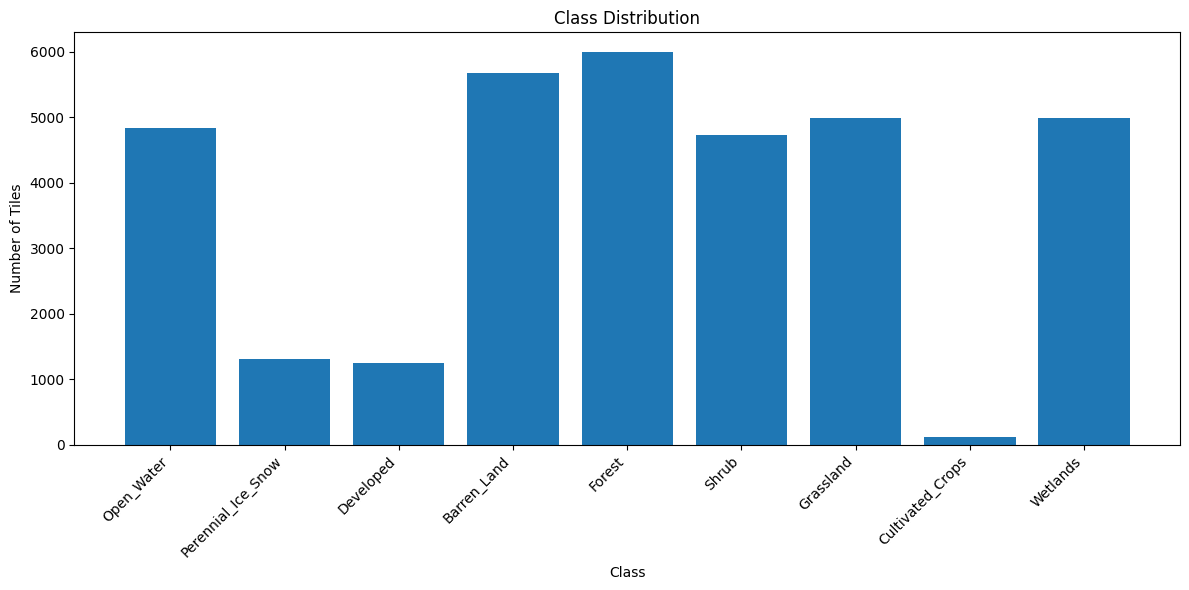


Imbalance ratio: 48.75:1
⚠️ WARNING: Significant class imbalance detected!


In [ ]:
# Add this cell to check class distribution
import numpy as np
import matplotlib.pyplot as plt

# Count samples per class
class_counts = {}
for class_name, label_value in class_data.items():
    count = np.sum(all_labels_raw == label_value)
    class_counts[class_name] = count
    print(f"{class_name}: {count} tiles")

# Visualize
plt.figure(figsize=(12, 6))
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel('Class')
plt.ylabel('Number of Tiles')
plt.title('Class Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Check imbalance ratio
max_count = max(class_counts.values())
min_count = min(class_counts.values())
print(f"\nImbalance ratio: {max_count/min_count:.2f}:1")
if max_count/min_count > 3:
    print("⚠️ WARNING: Significant class imbalance detected!")

In [ ]:
# Are train and test from the same distribution?
# Check if stratified split is working
for class_name, label_value in class_data.items():
    train_count = np.sum(labels_train_raw == label_value)
    test_count = np.sum(labels_test_raw == label_value)
    train_pct = train_count / len(labels_train_raw) * 100
    test_pct = test_count / len(labels_test_raw) * 100
    print(f"{class_name}: Train={train_pct:.1f}% Test={test_pct:.1f}%")

Open_Water: Train=14.3% Test=14.3%
Perennial_Ice_Snow: Train=3.9% Test=3.9%
Developed: Train=3.7% Test=3.7%
Barren_Land: Train=16.7% Test=16.8%
Forest: Train=17.7% Test=17.7%
Shrub: Train=13.9% Test=13.9%
Grassland: Train=14.7% Test=14.7%
Cultivated_Crops: Train=0.4% Test=0.4%
Wetlands: Train=14.7% Test=14.7%


##**One-Hot Encoding Function**

In [ ]:
def one_hot_encode(labels, num_classes):
    """Convert labels to one-hot encoding"""
    labels = np.int16(labels)
    one_hot_array = np.zeros((len(labels), num_classes + 1), dtype=np.float32)
    for i, label in enumerate(labels):
        one_hot_array[i, label] = 1
    return one_hot_array

##**Enhanced Data Augmentation**

In [ ]:
def brightness_adjust(img, factor=None):
    """Adjust brightness randomly between 0.8 and 1.2"""
    if factor is None:
        factor = np.random.uniform(0.8, 1.2)
    return np.clip(img * factor, 0, 1)

def add_noise(img, noise_level=0.02):
    """Add random Gaussian noise"""
    noise = np.random.normal(0, noise_level, img.shape)
    return np.clip(img + noise, 0, 1)

def random_contrast(img, factor=None):
    """Adjust contrast randomly"""
    if factor is None:
        factor = np.random.uniform(0.8, 1.2)
    mean = np.mean(img)
    return np.clip((img - mean) * factor + mean, 0, 1)

def is_valid_tile(img, min_std=0.01, min_mean=0.05, max_zero_ratio=0.5):
    """
    Check if a tile is valid (has actual imagery)

    Parameters:
    - img: normalized image (0-1 range)
    - min_std: minimum standard deviation (rejects flat/uniform tiles)
    - min_mean: minimum mean value (rejects all-black tiles)
    - max_zero_ratio: maximum ratio of zero pixels allowed

    Returns:
    - True if tile is valid, False otherwise
    """
    # Check if tile is mostly zeros (black)
    zero_ratio = np.sum(img == 0) / img.size
    if zero_ratio > max_zero_ratio:
        return False

    # Check if tile has sufficient variation (not flat/uniform)
    tile_std = np.std(img)
    if tile_std < min_std:
        return False

    # Check if tile has sufficient brightness (not all dark)
    tile_mean = np.mean(img)
    if tile_mean < min_mean:
        return False

    return True

# Enhanced augmentation transforms with new functions
AUGMENTATION_TRANSFORMS = [
    lambda img: img,                                        # Original
    lambda img: np.rot90(img),                              # Rotate 90
    lambda img: np.fliplr(img),                             # Flip left-right
    lambda img: np.flipud(img),                             # Flip up-down
    lambda img: np.rot90(np.rot90(img)),                    # Rotate 180
    lambda img: np.transpose(img, (1, 0, 2)),               # Transpose
    lambda img: np.rot90(np.transpose(img, (1, 0, 2))),     # Transpose and rot90
    lambda img: np.fliplr(np.transpose(img, (1, 0, 2))),    # Transpose and flip lr
    lambda img: brightness_adjust(img),                     # Brightness adjust (NEW)
    lambda img: add_noise(img),                             # Add noise (NEW)
    lambda img: random_contrast(img),                       # Contrast adjust (NEW)
    lambda img: brightness_adjust(np.fliplr(img)),          # Combined augmentation
]

print(f"Total augmentation transforms available: {len(AUGMENTATION_TRANSFORMS)}")
print("Tile validation enabled to filter out black/invalid tiles")

Total augmentation transforms available: 12
Tile validation enabled to filter out black/invalid tiles


##**Data Generator Function**

In [ ]:
def data_generator(filepaths, labels_raw, batch_size, num_classes,
                   original_img_shape, target_tile_size, augment=True,
                   shuffle=True, validate_tiles=True, max_retries=5):
    """
    Generator that yields batches of (image, one_hot_label) tuples
    NOW WITH TILE VALIDATION to skip black/invalid tiles

    Parameters:
    - validate_tiles: if True, skip tiles that fail validation
    - max_retries: maximum attempts to find a valid tile before giving up
    """
    num_samples = len(filepaths)
    indices = list(range(num_samples))
    image_channels = original_img_shape[2]

    # Statistics tracking
    skipped_tiles = 0
    total_tiles = 0

    while True:
        if shuffle:
            random.shuffle(indices)

        for i in range(0, num_samples, batch_size):
            batch_indices = indices[i:i + batch_size]
            batch_images = []
            batch_labels = []

            for data_idx in batch_indices:
                img_path = filepaths[data_idx]
                label_value = labels_raw[data_idx]

                # Try to load a valid tile (with retries in case of bad data)
                valid_tile_found = False
                for retry in range(max_retries):
                    try:
                        # Load image and normalize
                        image = np.load(img_path).astype(np.float32) / 255.0

                        # Apply slicing to get the target_tile_size
                        if original_img_shape[0] > target_tile_size:
                            start_idx = (original_img_shape[0] - target_tile_size) // 2
                            end_idx = start_idx + target_tile_size
                            image = image[start_idx:end_idx, start_idx:end_idx, :]
                        elif original_img_shape[0] < target_tile_size:
                            raise ValueError(f"Original image size {original_img_shape[0]} is smaller than target tile size {target_tile_size}.")

                        # Apply augmentation (randomly choose one transform if augmenting)
                        if augment:
                            transform = random.choice(AUGMENTATION_TRANSFORMS)
                            image = transform(image)

                        # Validate tile if enabled
                        total_tiles += 1
                        if validate_tiles:
                            if is_valid_tile(image):
                                valid_tile_found = True
                                break
                            else:
                                skipped_tiles += 1
                                # If augmenting, try a different augmentation
                                if augment and retry < max_retries - 1:
                                    continue
                                else:
                                    # Skip this tile entirely
                                    break
                        else:
                            valid_tile_found = True
                            break

                    except Exception as e:
                        print(f"Error loading {img_path}: {e}")
                        break

                # Only add to batch if we found a valid tile
                if valid_tile_found:
                    batch_images.append(image)
                    batch_labels.append(label_value)

            # Only yield if we have images in the batch
            if len(batch_images) > 0:
                batch_images_array = np.array(batch_images, dtype=np.float32)
                batch_one_hot_labels = one_hot_encode(np.array(batch_labels), num_classes)
                yield batch_images_array, batch_one_hot_labels

            # Periodically report statistics
            if total_tiles > 0 and total_tiles % 10000 == 0:
                skip_rate = (skipped_tiles / total_tiles) * 100
                print(f"Tile validation stats: {skipped_tiles}/{total_tiles} skipped ({skip_rate:.2f}%)")

print("Data generator with tile validation defined successfully.")

Data generator with tile validation defined successfully.


## **Create Data Generators**


In [ ]:
# Batch size - optimized for memory
batch_size = 128

# Create generators for training and validation data
train_gen = data_generator(
    files_train, labels_train_raw, batch_size, Nclasses,
    sample_image_shape, TileSize, augment=True, shuffle=True
)

# Validation generator will NOT augment data and will not shuffle
val_gen = data_generator(
    files_test, labels_test_raw, batch_size, Nclasses,
    sample_image_shape, TileSize, augment=False, shuffle=False
)

# Calculate steps per epoch
steps_per_epoch_train = math.ceil(len(files_train) / batch_size)
steps_per_epoch_val = math.ceil(len(files_test) / batch_size)

print(f"\nTraining data will be served by generator in batches of {batch_size}.")
print(f"Total original training samples: {len(files_train)}")
print(f"Total original validation samples: {len(files_test)}")
print(f"Steps per training epoch: {steps_per_epoch_train}")
print(f"Steps per validation epoch: {steps_per_epoch_val}")

# Cleanup
Images_train = None
Images_test = None
labels_train = None
labels_test = None
one_hot_trainlabels = None
one_hot_testlabels = None
gc.collect()

print("Data generators are ready. Proceeding with model definition...")


Training data will be served by generator in batches of 128.
Total original training samples: 27095
Total original validation samples: 6774
Steps per training epoch: 212
Steps per validation epoch: 53
Data generators are ready. Proceeding with model definition...


##**Visualize Sample Training Images**

Batch shape: (128, 32, 32, 7)
Number of channels available: 7


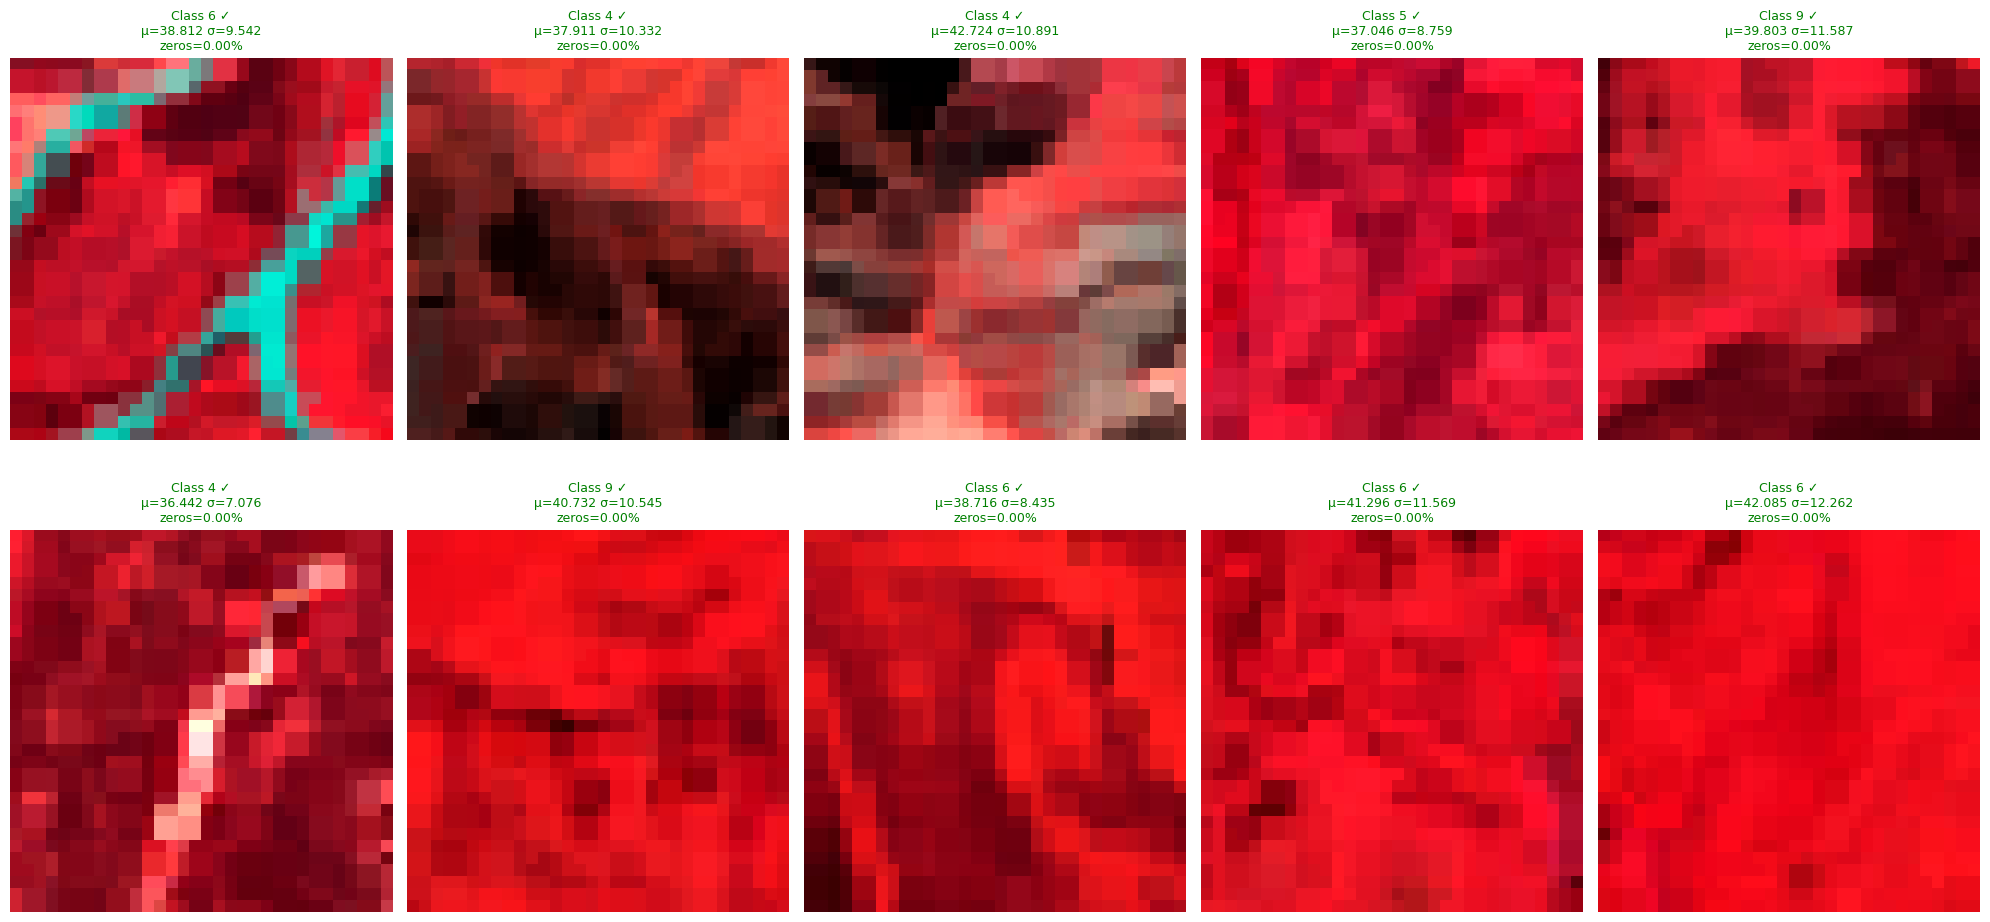


Batch validation: 128/128 tiles are valid (100.0%)


22245

In [ ]:
# Plot 10 random training images with the label as a title
temp_train_gen_iterator = iter(train_gen)
sample_images_batch, sample_labels_one_hot_batch = next(temp_train_gen_iterator)
num_images_to_plot = min(10, sample_images_batch.shape[0])
ims_indices_to_plot = np.random.choice(sample_images_batch.shape[0], num_images_to_plot, replace=False)

print(f"Batch shape: {sample_images_batch.shape}")
print(f"Number of channels available: {sample_images_batch.shape[3]}")

plt.figure(figsize=(20, 10))
for i, batch_idx in enumerate(ims_indices_to_plot):
    # Get single image from batch
    single_image = sample_images_batch[batch_idx]

    # Extract the three bands separately and stack them (assuming bands 5, 3, 2 for RGB)
    # Adjust these indices based on your actual band configuration
    if single_image.shape[2] > 5:
        band5 = single_image[:, :, 5]  # NIR or Red depending on your data
        band3 = single_image[:, :, 3]  # Green
        band2 = single_image[:, :, 2]  # Blue
    else:
        # Fallback if you have fewer bands
        band5 = single_image[:, :, min(2, single_image.shape[2]-1)]
        band3 = single_image[:, :, min(1, single_image.shape[2]-1)]
        band2 = single_image[:, :, 0]

    # Stack to create RGB image
    rgb = np.stack([band5, band3, band2], axis=2)

    # Check if tile is valid (for visualization purposes)
    tile_is_valid = is_valid_tile(single_image)
    tile_mean = np.mean(single_image)
    tile_std = np.std(single_image)
    zero_ratio = np.sum(single_image == 0) / single_image.size

    # Apply contrast stretching with robust percentiles
    p2 = np.percentile(rgb, 2)
    p98 = np.percentile(rgb, 98)

    # Avoid division by zero
    if p98 - p2 > 0:
        rgb_normalized = np.clip((rgb - p2) / (p98 - p2), 0, 1)
    else:
        rgb_normalized = rgb

    Im = np.uint8(255 * rgb_normalized)
    true_label = np.argmax(sample_labels_one_hot_batch[batch_idx])

    plt.subplot(2, 5, i + 1)
    plt.imshow(Im)

    # Create informative title
    validity_marker = "✓" if tile_is_valid else "✗"
    title = f'Class {true_label} {validity_marker}\n'
    title += f'μ={tile_mean:.3f} σ={tile_std:.3f}\n'
    title += f'zeros={zero_ratio:.2%}'

    plt.title(title, fontsize=9, color='green' if tile_is_valid else 'red')
    plt.axis('off')

    # Add border for invalid tiles
    if not tile_is_valid:
        ax = plt.gca()
        for spine in ax.spines.values():
            spine.set_edgecolor('red')
            spine.set_linewidth(3)

plt.tight_layout()
plt.show()

# Print validation statistics for this batch
valid_count = sum([is_valid_tile(sample_images_batch[i]) for i in range(sample_images_batch.shape[0])])
print(f"\nBatch validation: {valid_count}/{sample_images_batch.shape[0]} tiles are valid "
      f"({valid_count/sample_images_batch.shape[0]*100:.1f}%)")

# Clear sample data
del sample_images_batch, sample_labels_one_hot_batch, temp_train_gen_iterator
gc.collect()

##**Import TensorFlow and Define improved Model Architecture**

In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras import optimizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Flatten, Conv2D, MaxPooling2D, Dropout

print(f"TensorFlow version: {tf.__version__}")

# Create improved model
model = None
model = Sequential()

# Input layer
model.add(tf.keras.layers.InputLayer(input_shape=(TileSize, TileSize, sample_image_shape[2])))

# First Conv2D block
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same',
                 kernel_regularizer=regularizers.l2(0.001)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Second Conv2D block
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same',
                 kernel_regularizer=regularizers.l2(0.001)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Third Conv2D block
model.add(Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same',
                 kernel_regularizer=regularizers.l2(0.001)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Dense layers
model.add(Flatten())
model.add(Dense(128, kernel_regularizer=regularizers.l2(0.001), activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, kernel_regularizer=regularizers.l2(0.001), activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(Nclasses + 1, activation='softmax'))

# Create optimizer
LearningRate = 0.001
Optim = optimizers.Adam(learning_rate=LearningRate, beta_1=0.9, beta_2=0.999)

# Compile model
model.compile(loss='categorical_crossentropy', optimizer=Optim, metrics=['accuracy'])
model.summary()

TensorFlow version: 2.19.0


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 366,474 (1.40 MB)

 Trainable params: 366,026 (1.40 MB)

 Non-trainable params: 448 (1.75 KB)

##**Define Callbacks for Training**

In [ ]:
# Early stopping with increased patience
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,  # Increased from 10 to allow more learning
    restore_best_weights=True,
    verbose=1
)

# Learning rate reduction on plateau (NEW)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,  # Reduce LR by half
    patience=5,   # Wait 5 epochs before reducing
    min_lr=1e-7,
    verbose=1
)

# Model checkpoint to save best model
ModelName = 'MResCNNv4_IMPROVED'
Modelfullpath = f'/content/drive/MyDrive/MRes/CNN/Models/{ModelName}.keras'

checkpoint = ModelCheckpoint(
    Modelfullpath,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

print("Callbacks configured:")
print(f"- Early Stopping: patience={20}")
print(f"- ReduceLROnPlateau: factor=0.5, patience=5")
print(f"- ModelCheckpoint: saving to {Modelfullpath}")

Callbacks configured:
- Early Stopping: patience=20
- ReduceLROnPlateau: factor=0.5, patience=5
- ModelCheckpoint: saving to /content/drive/MyDrive/MRes/CNN/Models/MResCNNv4_IMPROVED.keras


##**Train the Model (main training cell)**

In [ ]:
# Training parameters
TrainingEpochs = 500

# Train the model with all callbacks
history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch_train,
    epochs=TrainingEpochs,
    validation_data=val_gen,
    validation_steps=steps_per_epoch_val,
    callbacks=[early_stopping, reduce_lr, checkpoint],  # All callbacks
    verbose=1
)

print(f"\nTraining complete! Best model saved to: {Modelfullpath}")

Epoch 1/500
211/212 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.2752 - loss: 2.6911
Epoch 1: val_accuracy improved from -inf to 0.22431, saving model to /content/drive/MyDrive/MRes/CNN/Models/MResCNNv4_IMPROVED.keras
212/212 ━━━━━━━━━━━━━━━━━━━━ 64s 246ms/step - accuracy: 0.2757 - loss: 2.6878 - val_accuracy: 0.2243 - val_loss: 2.6246 - learning_rate: 0.0010
Epoch 2/500
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.4139 - loss: 1.9451
Epoch 2: val_accuracy improved from 0.22431 to 0.29140, saving model to /content/drive/MyDrive/MRes/CNN/Models/MResCNNv4_IMPROVED.keras
212/212 ━━━━━━━━━━━━━━━━━━━━ 18s 84ms/step - accuracy: 0.4140 - loss: 1.9449 - val_accuracy: 0.2914 - val_loss: 2.3360 - learning_rate: 0.0010
Epoch 3/500
103/212 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.4501 - loss: 1.7743Tile validation stats: 32697/100000 skipped (32.70%)
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.4548 - loss: 1.7608
Epoch 3: val_accuracy improved from 0.29140 to 0.36

##**Save Model and Plot Training History**

Final model saved to: /content/drive/MyDrive/MRes/CNN/Models/MResCNNv4_IMPROVED.keras


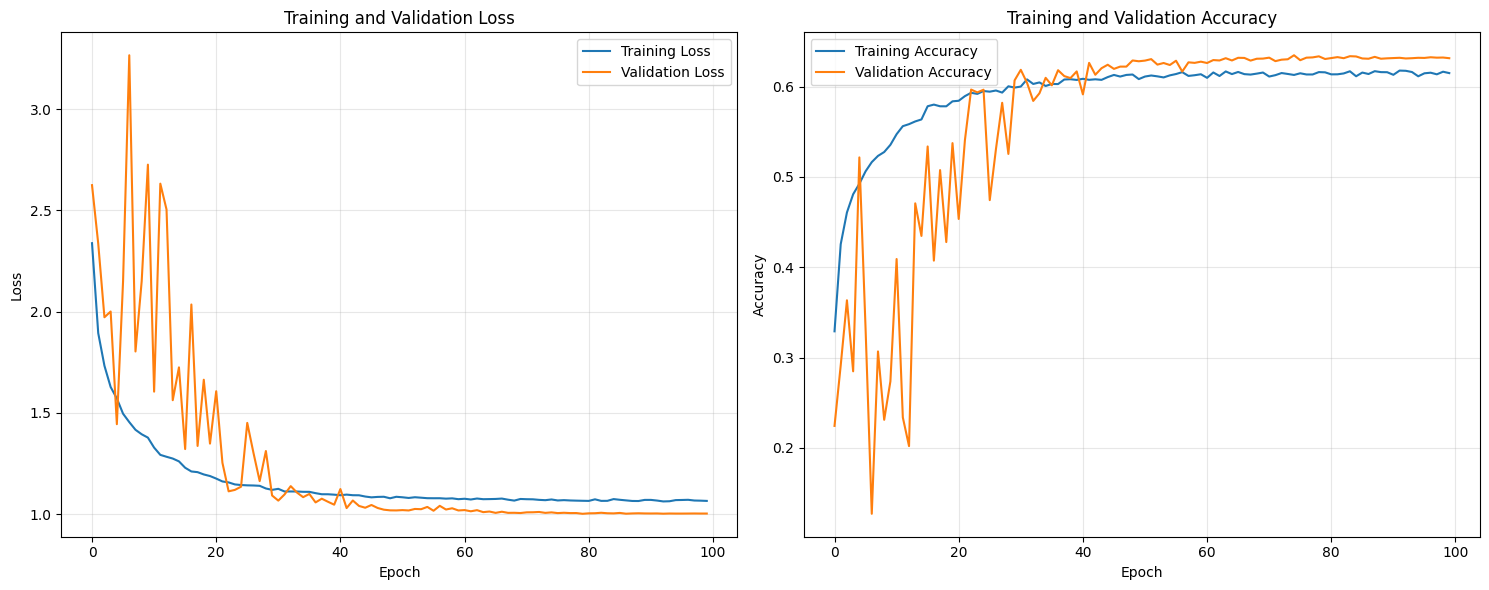


=== TRAINING SUMMARY ===
Final Training Accuracy: 0.6149
Final Validation Accuracy: 0.6314
Final Training Loss: 1.0650
Final Validation Loss: 1.0025
Best Validation Accuracy: 0.6347


In [ ]:
import os

# Save the final model (best weights already saved by checkpoint)
model.save(Modelfullpath)
print(f"Final model saved to: {Modelfullpath}")

# Plot training history
output_name = os.path.join('/content/drive/MyDrive/MRes/CNN/Models/', ModelName + '.png')
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

# Loss plot
axs[0].plot(history.history['loss'], label='Training Loss')
axs[0].plot(history.history['val_loss'], label='Validation Loss')
axs[0].set_title('Training and Validation Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Accuracy plot
axs[1].plot(history.history['accuracy'], label='Training Accuracy')
axs[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_name, dpi=450)
plt.show()

# Print final metrics
print("\n=== TRAINING SUMMARY ===")
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")
print(f"Best Validation Accuracy: {max(history.history['val_accuracy']):.4f}")

##**Inference - Test on Sample Tiles**

# Quick Start model if from previous runtime

In [ ]:
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

In [ ]:
!pip install imagecodecs -q

import numpy as np
import gc
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

print("✓ Environment ready!")

✓ Environment ready!


In [ ]:
Modelfullpath = '/content/drive/MyDrive/MRes/CNN/Models/MResCNNv4_IMPROVED.keras'

# Load model
print(f"Loading model from: {Modelfullpath}")
model = load_model(Modelfullpath)
print("✓ Model loaded successfully!")

# Set parameters (MUST MATCH TRAINING!)
TileSize = 32  # Change if you used different tile size
Nclasses = 9

# Define class mapping
class_data = {
    'Open_Water': 1,
    'Perennial_Ice_Snow': 2,
    'Developed': 3,
    'Barren_Land': 4,
    'Forest': 5,
    'Shrub': 6,
    'Grassland': 7,
    'Cultivated_Crops': 8,
    'Wetlands': 9,
}

# Define utility functions
def PadToTile(Im, size):
    if len(Im.shape) == 2:
        Im = Im.reshape(Im.shape[0], Im.shape[1], 1)
    pad_dim0 = size * (1 + (Im.shape[0] // size)) - Im.shape[0]
    pad_dim1 = size * (1 + (Im.shape[1] // size)) - Im.shape[1]
    padded_im = np.pad(Im, ((0, pad_dim0), (0, pad_dim1), (0, 0)), mode='symmetric')
    return padded_im

def split_image_to_tiles(im, size):
    if len(im.shape) == 2:
        h, w = im.shape
        d = 1
    else:
        h, w, d = im.shape
    nTiles_height = h // size
    nTiles_width = w // size
    TileTensor = np.zeros((nTiles_height * nTiles_width, size, size, d))
    B = 0
    for y in range(0, nTiles_height):
        for x in range(0, nTiles_width):
            x1 = np.int32(x * size)
            y1 = np.int32(y * size)
            x2 = np.int32(x1 + size)
            y2 = np.int32(y1 + size)
            TileTensor[B, :, :, :] = im[y1:y2, x1:x2, :].reshape(size, size, d)
            B += 1
    return TileTensor

def predict_tiles_in_batches(padded_image, tile_size, model, batch_size=10000):
    tiles = split_image_to_tiles(padded_image, tile_size)
    tiles = np.float32(tiles) / 255.0
    num_tiles = tiles.shape[0]
    all_predictions = []
    print(f"Predicting {num_tiles} tiles...")
    for i in range(0, num_tiles, batch_size):
        batch = tiles[i:i + batch_size]
        predictions = model.predict(batch, verbose=0)
        all_predictions.append(predictions)
        if (i // batch_size) % 10 == 0:
            print(f"  Progress: {min(i + batch_size, num_tiles)}/{num_tiles}")
        del batch
        gc.collect()
    del tiles
    gc.collect()
    return np.vstack(all_predictions)

def class_prediction_to_raster(ImSize, PredictedTiles, size):
    h, w, _ = ImSize
    nTiles_height = h // size
    nTiles_width = w // size
    expected_tiles = nTiles_height * nTiles_width
    num_predictions = PredictedTiles.shape[0]
    if num_predictions > expected_tiles:
        PredictedTiles = PredictedTiles[:expected_tiles]
    elif num_predictions < expected_tiles:
        raise ValueError(f"Expected {expected_tiles} predictions but got {num_predictions}")
    class_indices = np.argmax(PredictedTiles, axis=1).reshape(nTiles_height, nTiles_width)
    ClassRaster = np.zeros((h, w), dtype=np.uint8)
    for y in range(nTiles_height):
        for x in range(nTiles_width):
            x1, y1, x2, y2 = x * size, y * size, (x + 1) * size, (y + 1) * size
            if y2 <= h and x2 <= w:
                ClassRaster[y1:y2, x1:x2] = class_indices[y, x]
    return ClassRaster

print("✓ All functions defined!")
print(f"✓ TileSize: {TileSize}")
print(f"✓ Classes: {Nclasses}")

Loading model from: /content/drive/MyDrive/MRes/CNN/Models/MResCNNv4_IMPROVED.keras
✓ Model loaded successfully!
✓ All functions defined!
✓ TileSize: 32
✓ Classes: 9


Loading image...


/tmp/ipython-input-1803576726.py:13: FutureWarning: The plugin infrastructure in `skimage.io` and the parameter `plugin` are deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not use the parameter `plugin`. Instead, use `imageio` or other I/O packages directly. See also `imread`.
  S2 = io.imread(image_filename, plugin='tifffile')


Image shape: (9063, 7266, 7)
Predicting 64752 tiles...
  Progress: 10000/64752


/tmp/ipython-input-1803576726.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', Nclasses + 1)


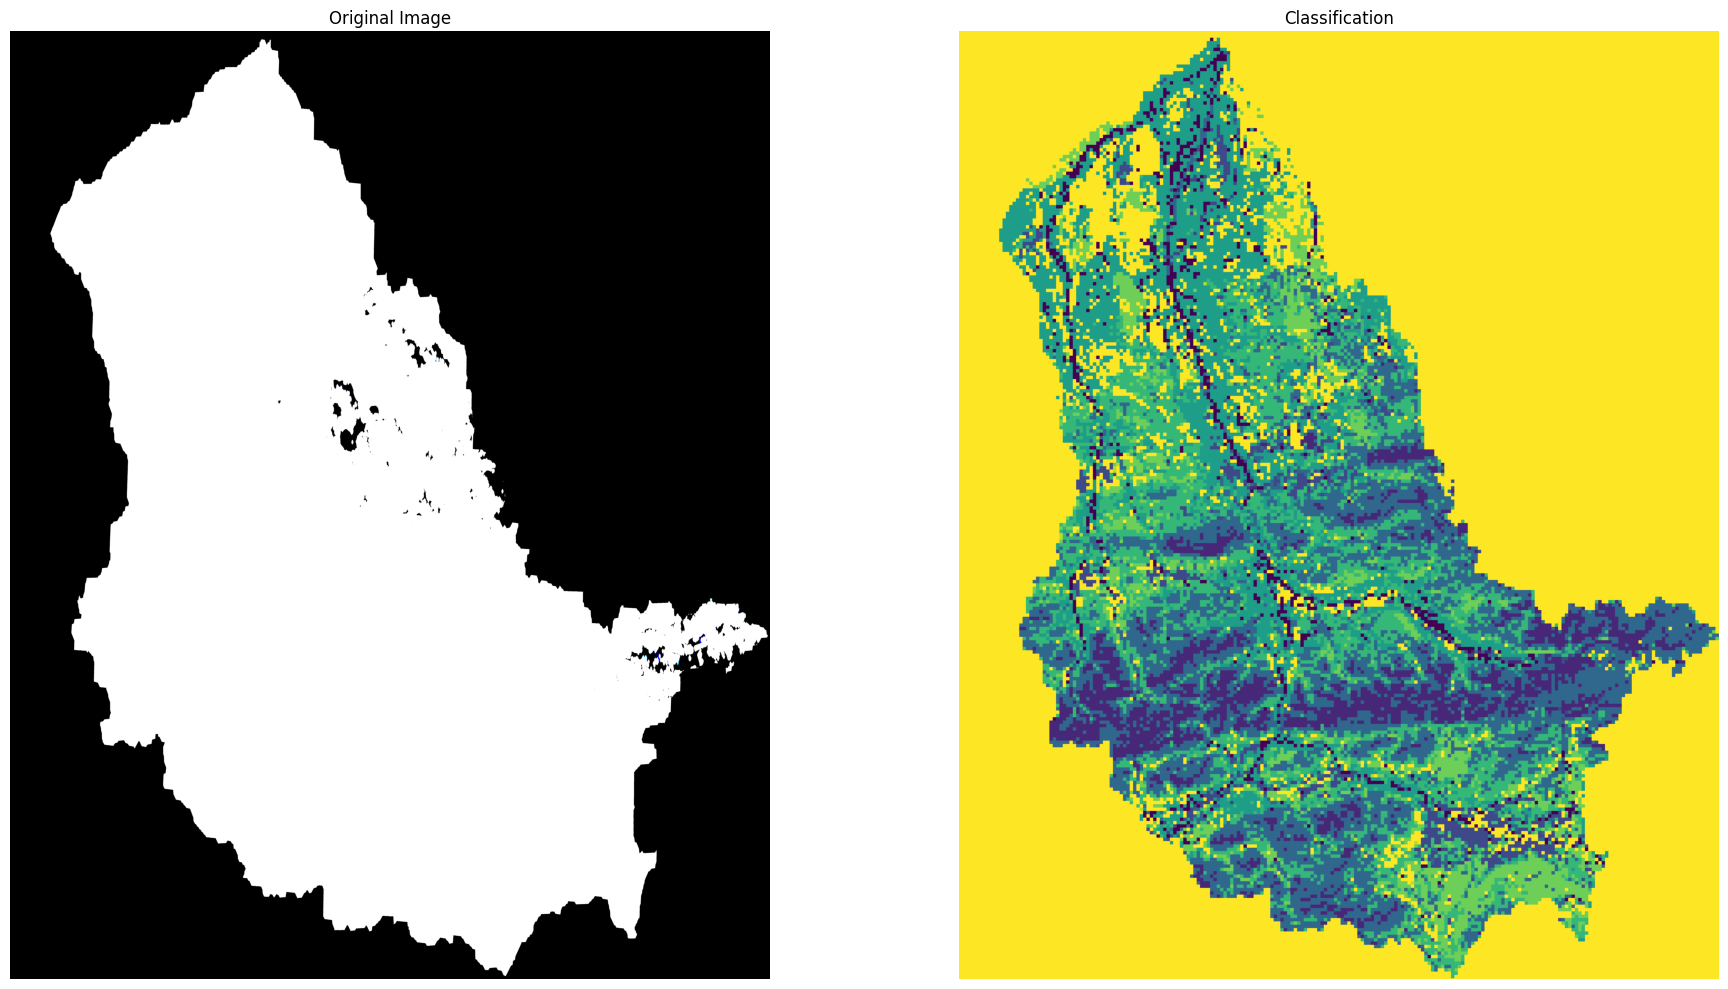


CLASSIFICATION REPORT
                    precision    recall  f1-score   support

        Open_Water     0.1140    0.2014    0.1456       700
Perennial_Ice_Snow     0.3763    0.6103    0.4655      1555
         Developed     0.9106    0.3111    0.4638      5403
       Barren_Land     0.2850    0.3160    0.2997      3934
            Forest     0.3242    0.6074    0.4228      1908
             Shrub     0.1002    0.1646    0.1245      1209
         Grassland     0.7231    0.5042    0.5941      1678
  Cultivated_Crops     0.0000    0.0000    0.0000         0
          Wetlands     0.4914    0.3914    0.4357      1528

          accuracy                         0.3805     17915
         macro avg     0.3694    0.3452    0.3280     17915
      weighted avg     0.5253    0.3805    0.3980     17915


Overall Accuracy: 0.3805


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me


✓ Inference complete!


In [ ]:
import skimage.io as io
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import gc

# --- UPDATE THESE PATHS ---
image_filename = '/content/drive/MyDrive/MRes/CNN/Test/TRV_Basin_LScomp2016_test_v3_repro.tif'
mask_filename = '/content/drive/MyDrive/MRes/CNN/Test/LScomp2016_test_poly.tif'

# Load image
print("Loading image...")
S2 = io.imread(image_filename, plugin='tifffile')
print(f"Image shape: {S2.shape}")

# Pad and predict
PadS2 = PadToTile(S2, TileSize)
SizePad = PadS2.shape  # Save shape before deleting to avoid NameError
PredictedTiles = predict_tiles_in_batches(PadS2, TileSize, model, batch_size=10000)
del PadS2
gc.collect()

# Create classification raster
PadClassRaster = class_prediction_to_raster(SizePad, PredictedTiles, TileSize)
ClassRaster = PadClassRaster[0:S2.shape[0], 0:S2.shape[1]]
del PadClassRaster, PredictedTiles
gc.collect()

# Visualize
cmap = plt.cm.get_cmap('viridis', Nclasses + 1)
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
axs[0].imshow(S2[:, :, :3] if S2.shape[2] >= 3 else S2[:, :, 0])
axs[0].set_title('Original Image')
axs[0].axis('off')
axs[1].imshow(ClassRaster, cmap=cmap)
axs[1].set_title('Classification')
axs[1].axis('off')
plt.tight_layout()
plt.show()

# Load mask and calculate accuracy
Mask = io.imread(mask_filename)
if len(Mask.shape) > 2:
    Mask = Mask[:, :, 0]
Mask = Mask[:ClassRaster.shape[0], :ClassRaster.shape[1]]
valid = Mask.ravel() != 0
ValidClassRaster = ClassRaster.ravel()[valid]
ValidMask = Mask.ravel()[valid]

# Classification report
class_names_list = [k for k, v in sorted(class_data.items(), key=lambda x: x[1])]
class_labels_list = sorted(list(class_data.values()))
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(ValidMask, ValidClassRaster,
                           target_names=class_names_list,
                           labels=class_labels_list, digits=4))
print(f"\nOverall Accuracy: {accuracy_score(ValidMask, ValidClassRaster):.4f}")

# Cleanup
del S2, ClassRaster, ValidClassRaster, ValidMask, Mask
gc.collect()
print("\n✓ Inference complete!")



---



In [ ]:
from tensorflow.keras.models import load_model

# Fetch a sample batch from the validation generator
temp_val_gen_iterator = iter(val_gen)
Tiles_batch, Labels_one_hot_batch = next(temp_val_gen_iterator)

num_tiles_to_predict = min(4, Tiles_batch.shape[0])
idx_to_predict = np.random.choice(Tiles_batch.shape[0], num_tiles_to_predict, replace=False)

Tiles = Tiles_batch[idx_to_predict]

# Predict the class of the tiles
CNN = load_model(Modelfullpath)
PredictedTiles = CNN.predict(Tiles, verbose=1)
print(f"Predictions shape: {PredictedTiles.shape}")

# Visualize predictions
plt.figure(figsize=(15, 20))
for i in range(num_tiles_to_predict):
    single_tile = Tiles[i]

    # Extract bands for visualization
    band5 = single_tile[:, :, 5] if single_tile.shape[2] > 5 else single_tile[:, :, 0]
    band3 = single_tile[:, :, 3] if single_tile.shape[2] > 3 else single_tile[:, :, 0]
    band2 = single_tile[:, :, 2] if single_tile.shape[2] > 2 else single_tile[:, :, 0]
    rgb = np.stack([band5, band3, band2], axis=2)

    # Apply contrast stretching
    p2, p98 = np.percentile(rgb, (2, 98))
    rgb_normalized = np.clip((rgb - p2) / (p98 - p2), 0, 1)
    Im = np.uint8(255 * rgb_normalized)

    # Create probability string
    prob_str = ''
    for class_idx in range(PredictedTiles.shape[1]):
        prob_str += f'C{class_idx}:{int(100*PredictedTiles[i, class_idx]):2d} '
    probTitle = prob_str.strip()

    plt.subplot(1, num_tiles_to_predict, i+1)
    plt.imshow(Im)
    plt.title(probTitle, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Clear prediction data
del Tiles_batch, Labels_one_hot_batch, Tiles, PredictedTiles, temp_val_gen_iterator
gc.collect()

NameError: name 'val_gen' is not defined

##**Utility Functions for Full Image Prediction**

In [ ]:
def PadToTile(Im, size):
    """Pad image to be divisible by tile size"""
    if len(Im.shape) == 2:
        Im = Im.reshape(Im.shape[0], Im.shape[1], 1)

    pad_dim0 = size * (1 + (Im.shape[0] // size)) - Im.shape[0]
    pad_dim1 = size * (1 + (Im.shape[1] // size)) - Im.shape[1]
    padded_im = np.pad(Im, ((0, pad_dim0), (0, pad_dim1), (0, 0)), mode='symmetric')

    return padded_im

def split_image_to_tiles(im, size):
    """Split image into tiles"""
    if len(im.shape) == 2:
        h, w = im.shape
        d = 1
    else:
        h, w, d = im.shape

    nTiles_height = h // size
    nTiles_width = w // size
    TileTensor = np.zeros((nTiles_height * nTiles_width, size, size, d))

    B = 0
    for y in range(0, nTiles_height):
        for x in range(0, nTiles_width):
            x1 = np.int32(x * size)
            y1 = np.int32(y * size)
            x2 = np.int32(x1 + size)
            y2 = np.int32(y1 + size)
            TileTensor[B, :, :, :] = im[y1:y2, x1:x2, :].reshape(size, size, d)
            B += 1

    return TileTensor

def predict_tiles_in_batches(padded_image, tile_size, model, batch_size=10000):
    """Predict tiles in batches to manage memory"""
    tiles = split_image_to_tiles(padded_image, tile_size)
    tiles = np.float32(tiles) / 255.0

    num_tiles = tiles.shape[0]
    all_predictions = []

    for i in range(0, num_tiles, batch_size):
        batch = tiles[i:i + batch_size]
        predictions = model.predict(batch, verbose=0)
        all_predictions.append(predictions)

        # Clear memory
        del batch
        gc.collect()

    del tiles
    gc.collect()

    return np.vstack(all_predictions)

def class_prediction_to_raster(ImSize, PredictedTiles, size):
    """Convert predicted tiles back to raster format"""
    h, w, _ = ImSize

    nTiles_height = h // size
    nTiles_width = w // size
    expected_tiles = nTiles_height * nTiles_width
    num_predictions = PredictedTiles.shape[0]

    if num_predictions > expected_tiles:
        PredictedTiles = PredictedTiles[:expected_tiles]
    elif num_predictions < expected_tiles:
        raise ValueError(f"Expected {expected_tiles} predictions but got {num_predictions}")

    class_indices = np.argmax(PredictedTiles, axis=1).reshape(nTiles_height, nTiles_width)

    ClassRaster = np.zeros((h, w), dtype=np.uint8)
    for y in range(nTiles_height):
        for x in range(nTiles_width):
            x1, y1, x2, y2 = x * size, y * size, (x + 1) * size, (y + 1) * size
            if y2 <= h and x2 <= w:
                ClassRaster[y1:y2, x1:x2] = class_indices[y, x]

    return ClassRaster

print("Utility functions defined successfully.")

Utility functions defined successfully.


##**Apply Model to Test Image with Validation Mask**

In [ ]:
!pip install imagecodecs
import imagecodecs
import skimage.io as io
from sklearn.metrics import classification_report

# Clear training data to save RAM
NewTensor = None
ImageTensor = None
Images_train = None
one_hot_trainlabels = None
Images_test = None
one_hot_testlabels = None
Tensor = None
gc.collect()

# Set the test image and mask to use
image_filename = '/content/drive/MyDrive/MRes/CNN/Test/TRV_Basin_LScomp2016_test_v3_repro.tif'
mask_filename = '/content/drive/MyDrive/MRes/CNN/Test/LScomp2016_test_poly.tif'

# Load the image
S2 = io.imread(image_filename, plugin='tifffile')
SizeS2 = S2.shape
print(f"Image shape: {SizeS2}")

# Pad to tile size
PadS2 = PadToTile(S2, TileSize)
SizePad = PadS2.shape
print(f"Padded shape: {SizePad}")

# Predict in batches
print("Predicting tiles...")
CNN = load_model(Modelfullpath)
PredictedTiles = predict_tiles_in_batches(PadS2, TileSize, CNN, batch_size=10000)
CNN = None
del PadS2
gc.collect()

# Make the class raster
print("Creating class raster...")
PadClassRaster = class_prediction_to_raster(SizePad, PredictedTiles, TileSize)
ClassRaster = PadClassRaster[0:SizeS2[0], 0:SizeS2[1]]
del PadClassRaster, PredictedTiles
gc.collect()

# Display the class raster
cmap = plt.cm.get_cmap('viridis', Nclasses + 1)

fig, axs = plt.subplots(2, 1, figsize=(15, 12))

axs[0].imshow(S2[:, :, :3])
axs[0].set_title('Original Image (RGB bands)')
axs[0].axis('off')

axs[1].imshow(ClassRaster, cmap=cmap)
axs[1].set_title('Predicted Classification')
axs[1].axis('off')

plt.tight_layout()
plt.show()

# Load and process mask
print("Loading validation mask...")
Mask = io.imread(mask_filename)

if len(Mask.shape) > 2:
    Mask = Mask[:, :, 0]

Mask = Mask[:ClassRaster.shape[0], :ClassRaster.shape[1]]

print(f"Mask shape: {Mask.shape}")
print(f"ClassRaster shape: {ClassRaster.shape}")

valid = Mask.ravel() != 0
print(f"Valid pixels in Mask: {np.sum(valid)}")

ValidClassRaster = ClassRaster.ravel()[valid]
ValidMask = Mask.ravel()[valid]
del Mask
gc.collect()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 66.5 MB/s eta 0:00:00


/tmp/ipython-input-551234818.py:21: FutureWarning: The plugin infrastructure in `skimage.io` and the parameter `plugin` are deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not use the parameter `plugin`. Instead, use `imageio` or other I/O packages directly. See also `imread`.
  S2 = io.imread(image_filename, plugin='tifffile')


Image shape: (9063, 7266, 7)
Padded shape: (9088, 7296, 7)
Predicting tiles...


NameError: name 'Modelfullpath' is not defined

##**Generate Classification Report**

In [ ]:
# Extract names and labels from class_data
class_names_9 = [k for k, v in sorted(class_data.items(), key=lambda item: item[1])]
class_labels_9 = sorted(list(class_data.values()))

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(ValidMask, ValidClassRaster,
                          target_names=class_names_9,
                          labels=class_labels_9,
                          digits=4))

# Calculate overall accuracy
from sklearn.metrics import accuracy_score
overall_accuracy = accuracy_score(ValidMask, ValidClassRaster)
print(f"\nOverall Accuracy: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")

##**Save Classified Image as GeoTIFF**

In [ ]:
from osgeo import gdal
!pip install rasterio
import rasterio

# Save classified raster
output_filename = image_filename.replace('.tif', '_classified_v4.tif')

ImageFile = gdal.Open(image_filename)
driver = gdal.GetDriverByName("GTiff")
outdata = driver.Create(output_filename, SizeS2[1], SizeS2[0], 1, gdal.GDT_Byte,
                       options=['COMPRESS=DEFLATE', 'PREDICTOR=2', 'ZLEVEL=9'])
outdata.SetGeoTransform(ImageFile.GetGeoTransform())
outdata.SetProjection(ImageFile.GetProjection())
outdata.GetRasterBand(1).WriteArray(ClassRaster)

# Apply 9-class color table
ct = gdal.ColorTable()
ct.SetColorEntry(1, (0, 0, 255))      # Open_Water: Blue
ct.SetColorEntry(2, (255, 255, 255))  # Perennial_Ice_Snow: White
ct.SetColorEntry(3, (255, 0, 0))      # Developed: Red
ct.SetColorEntry(4, (180, 180, 180))  # Barren_Land: Gray
ct.SetColorEntry(5, (0, 100, 0))      # Forest: Dark Green
ct.SetColorEntry(6, (150, 150, 0))    # Shrub: Olive
ct.SetColorEntry(7, (200, 255, 100))  # Grassland: Light Green
ct.SetColorEntry(8, (255, 255, 0))    # Cultivated_Crops: Yellow
ct.SetColorEntry(9, (0, 150, 150))    # Wetlands: Teal

outdata.GetRasterBand(1).SetRasterColorTable(ct)
outdata.FlushCache()
outdata = None
ImageFile = None

print(f"Classified image saved to: {output_filename}")

del ClassRaster, ValidClassRaster, ValidMask
gc.collect()

##**Apply to Unseen Images (Multi-Image Processing)**

In [ ]:
# Load the trained model
model = load_model(Modelfullpath)

# Define the folder containing unseen images
image_folder = '/content/drive/MyDrive/Diss/CNN/Unseen/Diss_Nor_LSComps_g50_v22/'
output_dir = os.path.join(image_folder, 'modelreturns/')
os.makedirs(output_dir, exist_ok=True)

# Find all files
image_filenames = sorted(glob.glob(os.path.join(image_folder, "**/*.tif"), recursive=True))

print(f"Found {len(image_filenames)} images to process")

# Process multiple images
for idx, image_filename in enumerate(image_filenames):
    print(f"\n[{idx+1}/{len(image_filenames)}] Processing: {os.path.basename(image_filename)}")
    try:
        with rasterio.open(image_filename) as src:
            S2 = src.read().transpose(1, 2, 0)
            SizeS2 = (src.height, src.width, src.count)

        PadS2 = PadToTile(S2, TileSize)
        SizePad = PadS2.shape
        del S2
        gc.collect()

        PredictedTiles = predict_tiles_in_batches(PadS2, TileSize, model, 10000)
        del PadS2
        gc.collect()

        PadClassRaster = class_prediction_to_raster(SizePad, PredictedTiles, TileSize)
        ClassRaster = PadClassRaster[:SizeS2[0], :SizeS2[1]]
        del PadClassRaster, PredictedTiles
        gc.collect()

        output_filename = os.path.join(output_dir, os.path.basename(image_filename).replace('.tif', '_class.tif'))

        ImageFile = gdal.Open(image_filename)
        driver = gdal.GetDriverByName("GTiff")
        outdata = driver.Create(output_filename, SizeS2[1], SizeS2[0], 1, gdal.GDT_Byte,
                               options=['NUM_THREADS=2', 'COMPRESS=DEFLATE', 'PREDICTOR=2', 'ZLEVEL=9'])
        outdata.SetGeoTransform(ImageFile.GetGeoTransform())
        outdata.SetProjection(ImageFile.GetProjection())
        outdata.GetRasterBand(1).WriteArray(ClassRaster)

        # 9-Class Color Table
        ct = gdal.ColorTable()
        ct.SetColorEntry(1, (0, 0, 255))      # Open_Water: Blue
        ct.SetColorEntry(2, (255, 255, 255))  # Perennial_Ice_Snow: White
        ct.SetColorEntry(3, (255, 0, 0))      # Developed: Red
        ct.SetColorEntry(4, (180, 180, 180))  # Barren_Land: Gray
        ct.SetColorEntry(5, (0, 100, 0))      # Forest: Dark Green
        ct.SetColorEntry(6, (150, 150, 0))    # Shrub: Olive
        ct.SetColorEntry(7, (200, 255, 100))  # Grassland: Light Green
        ct.SetColorEntry(8, (255, 255, 0))    # Cultivated_Crops: Yellow
        ct.SetColorEntry(9, (0, 150, 150))    # Wetlands: Teal
        outdata.GetRasterBand(1).SetRasterColorTable(ct)

        outdata.FlushCache()
        outdata = None
        ImageFile = None
        del ClassRaster
        gc.collect()

        print(f"✓ Successfully saved: {output_filename}")
    except Exception as e:
        print(f"✗ Error processing {image_filename}: {e}")

print("\n=== ALL PROCESSING COMPLETE ===")